In [4]:
import torch

print(torch.__version__)

2.13.0+cpu


In [5]:
import yfinance as yf

apple = yf.download("AAPL", period="5y")

apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-28,141.319519,143.259281,138.941122,141.153813,118931200
2021-07-29,141.962875,142.849903,140.929641,141.036864,56699500
2021-07-30,142.177292,142.635426,140.471476,140.734663,70440600
2021-08-02,141.845932,143.239820,141.582745,142.664720,62880000
2021-08-03,143.639420,144.302244,141.514453,142.128551,64786600


In [3]:
apple.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-07-19 to 2026-07-17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [4]:
apple.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,195.357898,197.305475,193.228365,195.147875,6.491026e+07
std,46.044365,46.417163,45.626714,45.980481,2.858682e+07
min,122.933548,125.637653,122.097738,123.907018,1.791060e+07
25%,157.910950,159.905126,155.627642,157.595867,4.569105e+07
50%,183.839081,185.233282,181.860468,183.925123,5.678790e+07
75%,227.315956,229.912809,225.600280,227.453220,7.681810e+07
max,333.739990,334.980011,329.000610,331.980011,3.186799e+08


In [6]:
close_prices = apple["Close"]

close_prices.head()

Ticker,AAPL
Date,
2021-07-28,141.319519
2021-07-29,141.962875
2021-07-30,142.177292
2021-08-02,141.845932
2021-08-03,143.639420


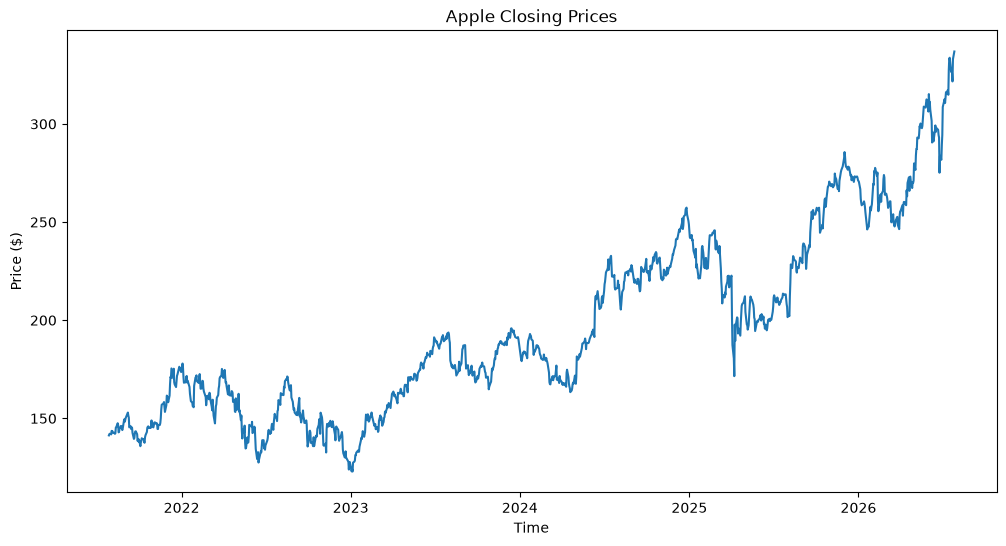

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(close_prices)

plt.title("Apple Closing Prices")
plt.xlabel("Time")
plt.ylabel("Price ($)")

plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(close_prices.values.reshape(-1, 1))

scaled_data[:5]

array([[0.08592517],
       [0.08893184],
       [0.0899339 ],
       [0.08838532],
       [0.09676702]])

In [9]:
lookback = 20

X = []
y = []

for i in range(len(scaled_data) - lookback):
    X.append(scaled_data[i:i + lookback])
    y.append(scaled_data[i + lookback])

In [10]:
print(len(X))
print(len(y))

1234
1234


In [11]:
print(X[0])

[[0.08592517]
 [0.08893184]
 [0.0899339 ]
 [0.08838532]
 [0.09676702]
 [0.09489947]
 [0.0954005 ]
 [0.09220685]
 [0.09197887]
 [0.08974357]
 [0.09092939]
 [0.10475317]
 [0.1057113 ]
 [0.11492691]
 [0.11068393]
 [0.09321069]
 [0.09476184]
 [0.10155952]
 [0.10849419]
 [0.10808345]]


In [12]:
print(y[0])

[0.10233503]


In [13]:
import numpy as np

X = np.array(X)
y = np.array(y)

In [14]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [15]:
print(X.shape)
print(y.shape)

(1234, 20, 1)
(1234, 1)


In [16]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [17]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(987, 20, 1)
(247, 20, 1)
(987, 1)
(247, 1)


In [18]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [19]:
print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(y_train.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([987, 20, 1])
torch.Size([987, 1])


In [21]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

C:\Users\sedat\AppData\Local\Temp\ipykernel_15980\3247396029.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\sedat\AppData\Local\Temp\ipykernel_15980\3247396029.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\sedat\AppData\Local\Temp\ipykernel_15980\3247396029.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
C:\Users\sedat\AppData\Local\Temp\ipykernel_1598

In [22]:
print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(y_train.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([987, 20, 1])
torch.Size([987, 1])


In [23]:
import torch.nn as nn

In [24]:
class LSTMModel(nn.Module):

    def __init__(self):
        super(LSTMModel, self).__init__()

In [29]:
class LSTMModel(nn.Module):

    def __init__(self):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, (hn, cn) = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [30]:
model = LSTMModel()

In [31]:
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [32]:
criterion = nn.MSELoss()

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [34]:
epochs = 100

for epoch in range(epochs):

    # Eğitim moduna geç
    model.train()

    # Önceki gradyanları temizle
    optimizer.zero_grad()

    # Tahmin yap
    outputs = model(X_train)

    # Hatayı hesapla
    loss = criterion(outputs, y_train)

    # Geri yayılım (Backpropagation)
    loss.backward()

    # Ağırlıkları güncelle
    optimizer.step()

    # Her 10 epoch'ta bir ekrana yazdır
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [10/100], Loss: 0.020386
Epoch [20/100], Loss: 0.019370
Epoch [30/100], Loss: 0.018520
Epoch [40/100], Loss: 0.014770
Epoch [50/100], Loss: 0.004575
Epoch [60/100], Loss: 0.003030
Epoch [70/100], Loss: 0.002103
Epoch [80/100], Loss: 0.001457
Epoch [90/100], Loss: 0.001225
Epoch [100/100], Loss: 0.001105


In [35]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

In [36]:
print(predictions.shape)

torch.Size([247, 1])


In [37]:
print(predictions[:5])

tensor([[0.4068],
        [0.4037],
        [0.4002],
        [0.3964],
        [0.3950]])


In [38]:
predictions = predictions.numpy()
y_test = y_test.numpy()

In [39]:
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

In [40]:
print(predictions[:5])
print(y_test[:5])

[[209.97974]
 [209.31902]
 [208.57378]
 [207.75702]
 [207.44803]]
[[201.5803 ]
 [202.54645]
 [202.11815]
 [212.40735]
 [219.16054]]


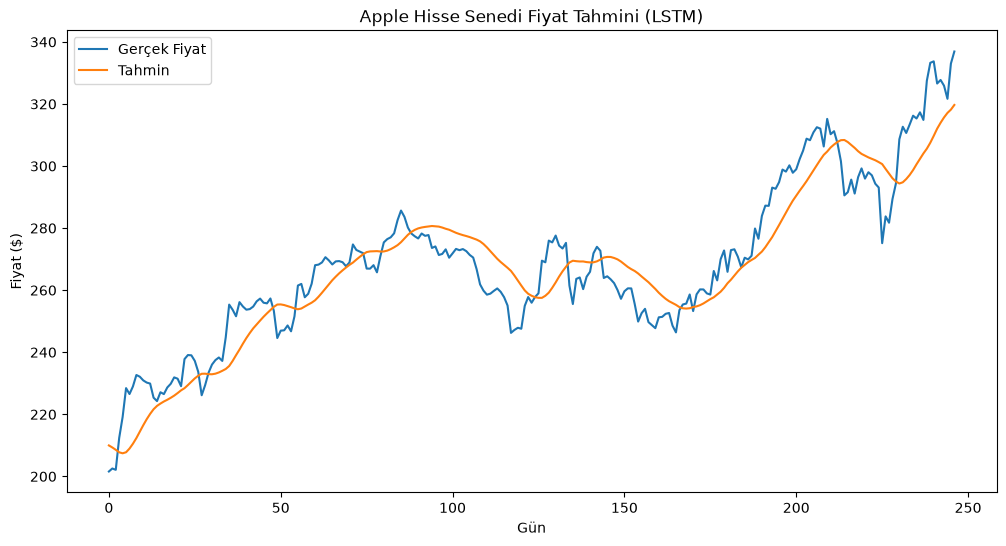

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test, label="Gerçek Fiyat")
plt.plot(predictions, label="Tahmin")

plt.title("Apple Hisse Senedi Fiyat Tahmini (LSTM)")
plt.xlabel("Gün")
plt.ylabel("Fiyat ($)")
plt.legend()

plt.show()

In [43]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 9.862736293732436


In [44]:
class GRUModel(nn.Module):

    def __init__(self):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

In [45]:
class GRUModel(nn.Module):

    def __init__(self):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, hn = self.gru(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [46]:
gru_model = GRUModel()

In [47]:
gru_criterion = nn.MSELoss()

In [48]:
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

In [49]:
gru_epochs = 100

for epoch in range(gru_epochs):

    # Eğitim moduna geç
    gru_model.train()

    # Önceki gradyanları temizle
    gru_optimizer.zero_grad()

    # Tahmin yap
    outputs = gru_model(X_train)

    # Hatayı hesapla
    loss = gru_criterion(outputs, y_train)

    # Geri yayılım
    loss.backward()

    # Ağırlıkları güncelle
    gru_optimizer.step()

    # Her 10 epoch'ta bir ekrana yazdır
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{gru_epochs}], Loss: {loss.item():.6f}")

Epoch [10/100], Loss: 0.025897
Epoch [20/100], Loss: 0.017258
Epoch [30/100], Loss: 0.014957
Epoch [40/100], Loss: 0.011073
Epoch [50/100], Loss: 0.004429
Epoch [60/100], Loss: 0.001494
Epoch [70/100], Loss: 0.000670
Epoch [80/100], Loss: 0.000731
Epoch [90/100], Loss: 0.000600
Epoch [100/100], Loss: 0.000534


In [50]:
gru_model.eval()

with torch.no_grad():
    gru_predictions = gru_model(X_test)

In [51]:
gru_predictions = gru_predictions.numpy()

In [52]:
gru_predictions = scaler.inverse_transform(gru_predictions)

In [53]:
print(gru_predictions[:5])

[[209.89989]
 [207.99089]
 [206.37515]
 [205.07573]
 [205.98085]]


In [54]:
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))

print("GRU RMSE:", gru_rmse)

GRU RMSE: 7.39217742680565
